# 02 · Deep models, tested honestly

BME AI-Studio trains one small network per sensor cycle. This notebook compares three models on the same data:

| model | input | idea |
|---|---|---|
| `MLP` | one sensor's cycle, `(F,)` | AI-Studio's network: standardise → dense 10 → dense 10 → softmax |
| `SensorSetNet` | all 8 sensors at one moment, `(S, F)` | a shared encoder reads each sensor's cycle, a learned embedding says which sensor it is, attention decides how much each counts; copes with a missing sensor |
| `TemporalNet` | 6 consecutive moments, `(L, S, F)` | SensorSetNet's encoding of each moment, then a GRU over time |

Every model is scored two ways: **honestly** (tested on specimens it never trained on) and on a **random split** of
cycles, which is what AI-Studio reports. Notebook 01 explains why these differ.

**Data.** It uses BME AI-Studio's demo project (a La Marzocco coffee-machine session). You need AI-Studio installed for
it, or point `DEMO` at your own data (see the next cell). Training runs on the GPU if there is one.

> **Whose data is this?** Every result in this notebook comes from **Bosch's demo dataset**, which ships inside BME
> AI-Studio: a 2.5-hour session Bosch recorded next to a La Marzocco espresso machine, on their older **BME688**
> development kit, labelled Air, Espresso Coffee and Filter Coffee. It is *not* data from your board, and not from a
> BME690. It is used here because it is the only labelled gas-sensor data available to everyone, and because it lets
> these tools be checked against AI-Studio's own numbers.
>
> **To run this on your own recordings**, set `recs = lab.load("<your SD card>/bme690")` in the first code cell. Your
> recordings need at least two labelled classes (e.g. coffee and air) to train anything; BME Studio's Quick experiment
> records them that way.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from bme690 import lab
from bme690.lab import models, train, augment, export

# BME AI-Studio keeps its demo project inside its install folder: here /opt/bme-ai-studio (the Linux repack);
# on Windows, resources/app.asar.unpacked/src/config/demo.bmeproject under the AI-Studio folder.
DEMO = Path("/opt/bme-ai-studio/app/src/config/demo.bmeproject")
recs = lab.load_aistudio(DEMO)
# Your own recordings instead:  recs = lab.load("/media/<you>/SDCARD/bme690")

OUT = Path("output"); OUT.mkdir(exist_ok=True)
DEVICE = "auto"                     # "cuda", "cpu", or "auto" = the GPU when there is one
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
df = lab.cycles_table(recs)
recs[0].specimens[["name", "cls", "start", "end"]].assign(cycles=df.groupby("specimen").size())

,name,cls,start,end,cycles
0,Warm-Up,NaN,0.0,956545.0,360
1,Neutral Air,Air,958072.0,1916308.0,356
2,Espresso Coffee,Espresso,1917034.0,3783302.0,699
3,Neutral Air,Air,3783520.0,4761078.0,363
4,Filter Coffee,Filter Coffee,4761373.0,6838432.0,775
5,Neutral Air,Air,6838601.0,8721072.0,695


## What this data can and cannot tell us

One recording, 145 minutes, 8 sensors. The sensors run **four different heater profiles in pairs** (0–1, 2–3, 4–5,
6–7), with cycles from 10 s to 31 s long. There are six specimens: a warm-up (no class), **three** stretches of
neutral air, **one** espresso and **one** filter coffee.

* **Air vs Coffee** has 3 air specimens and 2 coffee specimens, so leave-one-specimen-out cross-validation works: each
  fold tests one whole specimen with a model trained on the other four. When the test specimen is the espresso, the
  model has only seen filter coffee as "Coffee", which is a real test of generalisation.
* **Espresso vs Filter Coffee vs Air** has a **single** specimen of each coffee. There is no way to test on an espresso
  the model has not trained on, so the best available split trains on the first 70 % of each coffee and tests on the
  last 30 %, which is **still the same cup**. That score is optimistic. It shows the model can tell *this* espresso from
  *this* filter coffee, not that it would recognise tomorrow's espresso.

In [2]:
AIR_COFFEE = {"Air": "Air", "Espresso": "Coffee", "Filter Coffee": "Coffee"}
THREE_WAY  = {"Air": "Air", "Espresso": "Espresso", "Filter Coffee": "Filter Coffee"}

def datasets(classes):
    per = lab.per_sensor(df, classes=classes)           # AI-Studio's way: one sample per sensor-cycle
    fa  = lab.fused_all(df, classes=classes)            # all 8 sensors at each moment, NaN when a sensor has no fresh cycle
    seq = lab.sequences(fa, length=6)                   # 6 consecutive moments (about a minute)
    return {"MLP": per, "SensorSetNet": fa, "TemporalNet": seq}

hp = df[df.cls.notna()].heater_profile.value_counts().idxmax()
for name, s in datasets(AIR_COFFEE).items():
    print(f"{name:13s} X {str(s.X.shape):18s} labels {s.labels}  samples per label {np.bincount(s.y).tolist()}")
print(f"\nper_sensor uses the most common heater profile, {hp} (sensors 0 and 1), as AI-Studio trains per profile.")
print(f"fused_all: {np.isnan(datasets(AIR_COFFEE)['SensorSetNet'].X[..., 0]).mean():.1%} of sensor slots are missing (start of a specimen)")

MLP           X (1458, 11)         labels ['Air', 'Coffee']  samples per label [715, 743]
SensorSetNet  X (729, 8, 11)       labels ['Air', 'Coffee']  samples per label [358, 371]
TemporalNet   X (704, 6, 8, 11)    labels ['Air', 'Coffee']  samples per label [343, 361]

per_sensor uses the most common heater profile, heater_354 (sensors 0 and 1), as AI-Studio trains per profile.
fused_all: 1.5% of sensor slots are missing (start of a specimen)


## The models and their training settings

The MLP uses AI-Studio's settings (Adam, learning rate 0.001, batch 32). The deep models train with physically
plausible augmentations: each sensor's level drifts by about 7 %, 1 % read-out noise, a sensor randomly goes missing,
and consecutive cycles in a sequence jitter. Every run is seeded, and class weights balance the labels.

In [3]:
AUG = augment.Augment("shape", drift=0.03, noise=0.005, dropout=0.15, jitter=0.1)
print(AUG)

SPECS = {
    "MLP":          (lambda s: models.MLP.for_samples(s),
                     dict(epochs=100, batch_size=32, lr=1e-3)),
    "SensorSetNet": (lambda s: models.SensorSetNet.for_samples(s, dim=32),
                     dict(epochs=80, batch_size=64, lr=1e-3, weight_decay=1e-4, augment=AUG)),
    "TemporalNet":  (lambda s: models.TemporalNet.for_samples(s, dim=32, hidden=32),
                     dict(epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4, augment=AUG)),
}
for name, (make, _) in SPECS.items():
    s = datasets(AIR_COFFEE)[name]
    print(f"{name:13s} {sum(p.numel() for p in make(s).parameters()):6d} parameters")

Augment('shape', drift=0.03, noise=0.005, dropout=0.15, jitter=0.1)
MLP              252 parameters
SensorSetNet    8563 parameters
TemporalNet    14899 parameters


In [4]:
def fit_once(name, s, tr, te, val=True, seed=0):
    make, kw = SPECS[name]
    train.seed_everything(seed)
    m = make(s)
    h = train.fit(m, s.subset(tr), s.subset(te) if val else None, device=DEVICE, progress=False, seed=seed, **kw)
    return m, h, train.evaluate(m, s.subset(te))

train.device_of(DEVICE);   # says which device trains

training on NVIDIA GeForce RTX 4090 (cuda:0)


## Air vs Coffee: leave one specimen out

`lab.group_kfold(s, k=5)` with five labelled specimens holds out one whole specimen per fold. The **honest** score
pools the five folds' predictions. The **random** score trains on a random 70 % of cycles and tests on the rest, as
AI-Studio does.

In [5]:
rows, cv_results, t0 = [], {}, time.time()
for name, s in datasets(AIR_COFFEE).items():
    make, kw = SPECS[name]
    print(name)
    cv = train.cross_validate(make, s, lab.group_kfold(s, k=5), device=DEVICE, **kw)
    cv_results[name] = cv
    _, _, rnd = fit_once(name, s, *lab.random_split(len(s)), val=False)
    rows.append({"task": "Air vs Coffee", "model": name, "honest": cv["pooled_accuracy"],
                 "honest fold mean": cv["mean"], "fold std": cv["std"], "random split": rnd["accuracy"]})
print(f"{time.time() - t0:.0f} s")

names = {g: f"{recs[0].specimens['name'].iat[int(g.split(':')[1])]} (#{g.split(':')[1]})" for g in df.group.unique()}
pd.DataFrame({name: {names[f["test_groups"][0]]: f["accuracy"] for f in cv["folds"]}
              for name, cv in cv_results.items()}).style.format("{:.3f}").set_caption("accuracy on each held-out specimen")

MLP


  fold 1/5: 0.966 on 352 samples (LaMarzocco Session:5)


  fold 2/5: 1.000 on 180 samples (LaMarzocco Session:1)


  fold 3/5: 0.977 on 352 samples (LaMarzocco Session:2)


  fold 4/5: 1.000 on 183 samples (LaMarzocco Session:3)


...

  fold 3/5: 1.000 on 171 samples (LaMarzocco Session:2)


  fold 4/5: 1.000 on 87 samples (LaMarzocco Session:3)


  fold 5/5: 1.000 on 190 samples (LaMarzocco Session:4)
  mean 0.996 ± 0.007  (pooled 0.996)


169 s


,MLP,SensorSetNet,TemporalNet
Neutral Air (#5),0.966,0.994,0.982
Neutral Air (#1),1.000,1.000,1.000
Espresso Coffee (#2),0.977,0.994,1.000
Neutral Air (#3),1.000,1.000,1.000
Filter Coffee (#4),1.000,1.000,1.000


## Espresso vs Filter Coffee vs Air: the optimistic one

`split_by_specimen` holds out one whole air specimen, but for the coffees, which have one specimen each, it falls back to a
**time split inside the same specimen**, and `split_warning` says so.

**What would fix it:** brew each coffee at least 3–5 separate times (different cups, ideally different days), with air
between them, and log them all with the board. Then `group_kfold` can hold out whole brews, and with several sessions
`leave_one_recording_out` tests whether the model survives a new day, which is the question that matters in practice.

In [6]:
three = datasets(THREE_WAY)
print("⚠ ", lab.split_warning(three["MLP"]))
fits3 = {}
for name, s in three.items():
    tr, te = lab.split_by_specimen(s)
    m, h, hon = fit_once(name, s, tr, te)
    _, _, rnd = fit_once(name, s, *lab.random_split(len(s)), val=False)
    fits3[name] = (m, h, hon, s.subset(te))
    rows.append({"task": "Espresso vs Filter vs Air", "model": name, "honest": hon["accuracy"],
                 "honest fold mean": np.nan, "fold std": np.nan, "random split": rnd["accuracy"]})
    print(f"{name:13s} honest-ish {hon['accuracy']:.3f}   random {rnd['accuracy']:.3f}   recall " +
          ", ".join(f"{k} {v:.2f}" for k, v in hon["recall"].items()))

⚠  Espresso, Filter Coffee have only one specimen, so its test data comes from the end of that same specimen and the score is optimistic.


MLP           honest-ish 0.908   random 0.963   recall Air 1.00, Espresso 0.92, Filter Coffee 0.62


SensorSetNet  honest-ish 0.963   random 0.995   recall Air 1.00, Espresso 1.00, Filter Coffee 0.81


TemporalNet   honest-ish 0.961   random 1.000   recall Air 1.00, Espresso 1.00, Filter Coffee 0.81


task,model,honest,honest fold mean,fold std,random split
Air vs Coffee,MLP,0.986,0.989,0.014,0.993
Air vs Coffee,SensorSetNet,0.997,0.998,0.003,0.995
Air vs Coffee,TemporalNet,0.996,0.996,0.007,1.000
Espresso vs Filter vs Air,MLP,0.908,–,–,0.963
Espresso vs Filter vs Air,SensorSetNet,0.963,–,–,0.995
Espresso vs Filter vs Air,TemporalNet,0.961,–,–,1.000


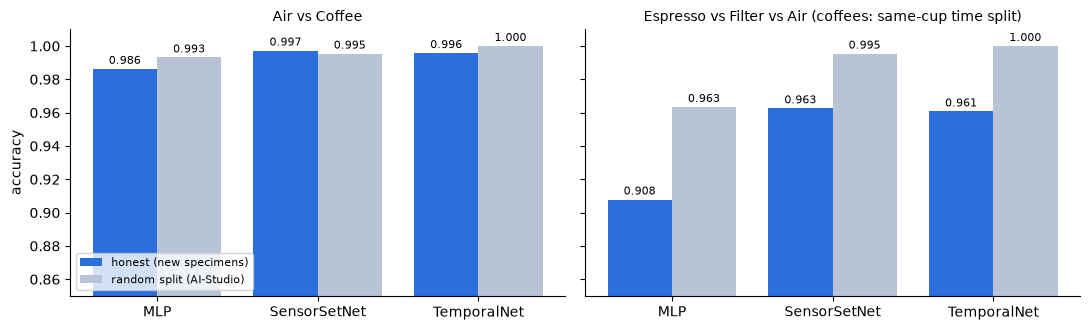

In [7]:
res = pd.DataFrame(rows)
display(res.style.format({c: "{:.3f}" for c in ["honest", "honest fold mean", "fold std", "random split"]}, na_rep="–")
        .hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (task, r) in zip(axes, res.groupby("task", sort=False)):
    x = np.arange(len(r))
    ax.bar(x - 0.2, r["honest"], 0.4, label="honest (new specimens)", color="#2a6fdb")
    ax.bar(x + 0.2, r["random split"], 0.4, label="random split (AI-Studio)", color="#b8c4d6")
    for i, (h, rn) in enumerate(zip(r["honest"], r["random split"])):
        ax.text(i - 0.2, h + 0.003, f"{h:.3f}", ha="center", fontsize=8)
        ax.text(i + 0.2, rn + 0.003, f"{rn:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x, r["model"]); ax.set_title(task + (" (coffees: same-cup time split)" if "Filter" in task else ""), fontsize=10)
    ax.set_ylim(0.85, 1.01)
axes[0].set_ylabel("accuracy"); axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()

The samples are not the same unit for every model: the MLP scores single sensor-cycles, SensorSetNet scores moments
(all sensors), and TemporalNet scores one-minute windows. More context per decision usually means higher accuracy,
so compare the gap between honest and random within a model more than the absolute numbers across models.

## Learning curves

These are for the three-way task. The validation curve is the held-out part, plotted but not used to stop training.

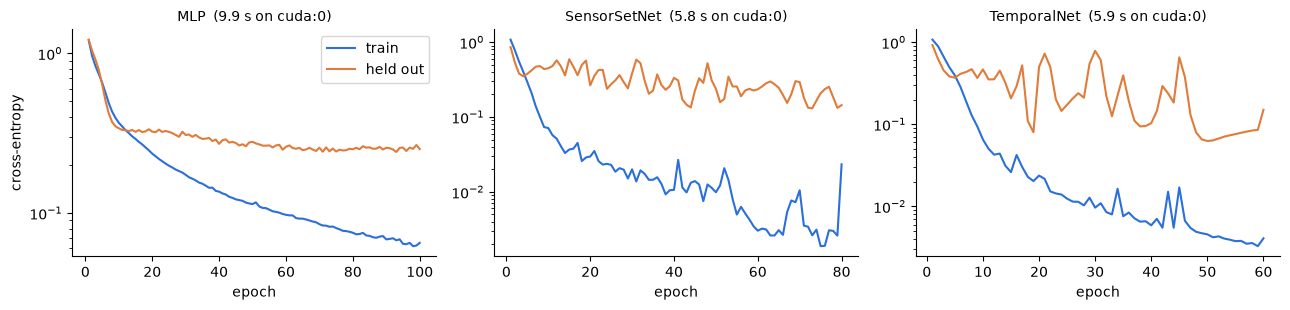

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (name, (m, h, hon, te)) in zip(axes, fits3.items()):
    ax.plot(h["epoch"], h["loss"], label="train", color="#2a6fdb")
    ax.plot(h["epoch"], h["val_loss"], label="held out", color="#e07b39")
    ax.set_yscale("log"); ax.set_title(f"{name}  ({h['seconds']:.1f} s on {h['device']})", fontsize=10)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy"); axes[0].legend()
plt.tight_layout()

## Confusion matrices

Rows are the true label and columns the prediction. Left: three-way task, same-cup time split for the coffees. Right:
Air vs Coffee, pooled over the leave-one-specimen-out folds.

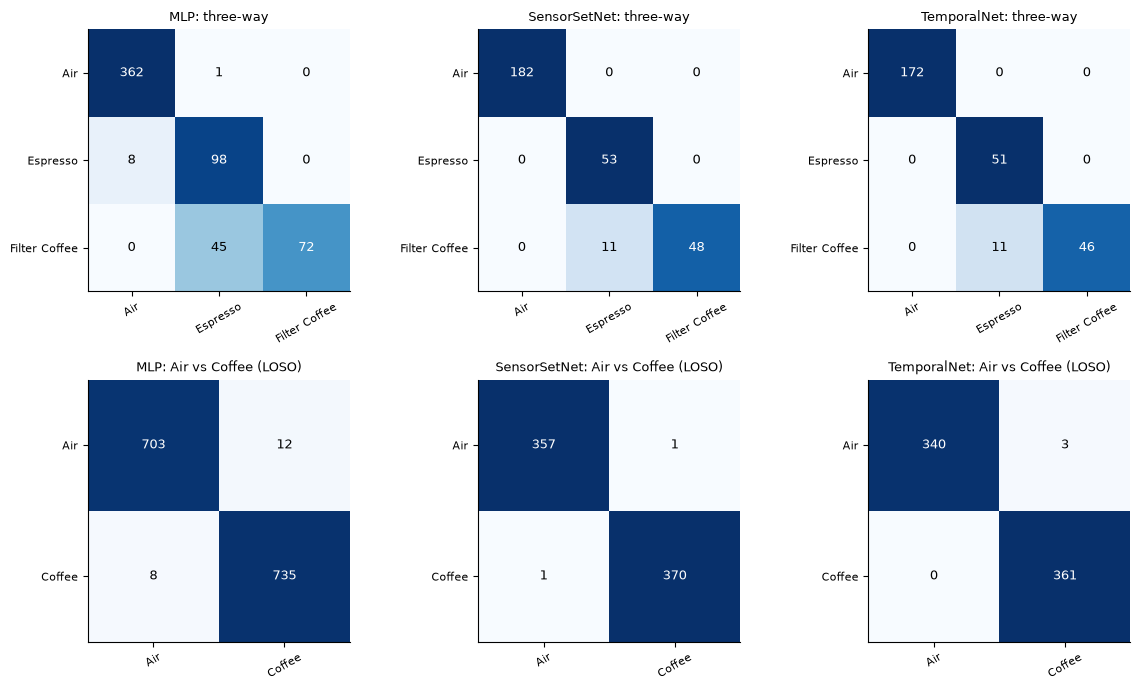

In [9]:
def confusion(ax, c, labels, title):
    ax.imshow(c / np.maximum(c.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, int(c[i, j]), ha="center", va="center", fontsize=9,
                    color="white" if c[i, j] > 0.6 * c[i].sum() else "black")
    ax.set_xticks(range(len(labels)), labels, rotation=30, fontsize=8); ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for k, (name, (m, h, hon, te)) in enumerate(fits3.items()):
    confusion(axes[0, k], hon["confusion"], hon["labels"], f"{name}: three-way")
    confusion(axes[1, k], cv_results[name]["confusion"], ["Air", "Coffee"], f"{name}: Air vs Coffee (LOSO)")
plt.tight_layout()

## Which sensors does SensorSetNet listen to?

Two views of the three-way SensorSetNet, both on the held-out data: the **attention weight** it gives each sensor (by
true label), and how much accuracy drops when a sensor is **removed** (its row set to missing, which the model
handles). Attention shows where the model looks, and the removal test shows which sensors it depends on.

all sensors: 0.963 | without each: [0.956, 0.969, 0.983, 0.959, 0.952, 0.963, 0.963, 0.963]


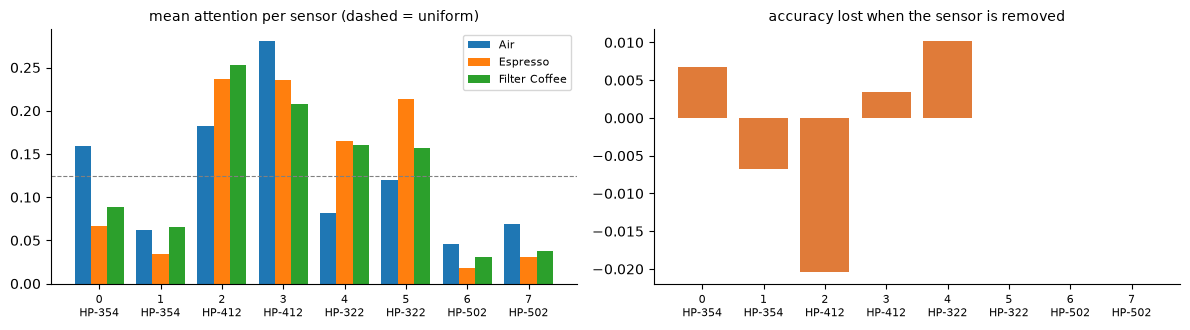

In [10]:
m, h, hon, te = fits3["SensorSetNet"]
p = train.predict_proba(m, te)
att = m.attention().cpu().numpy()                       # (N, S) from that forward pass
profile = {c["sensorIndex"]: c["heaterProfile"].replace("heater_", "HP-") for c in recs[0].config["sensors"]}
sens = te.sensors
drop = []
for j in range(len(sens)):
    t2 = te.subset(np.arange(len(te))); t2.X = te.X.copy(); t2.X[:, j] = np.nan
    drop.append(hon["accuracy"] - train.evaluate(m, t2)["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
w = 0.8 / len(te.labels)
for k, lab_ in enumerate(te.labels):
    axes[0].bar(np.arange(len(sens)) + (k - 1) * w, att[te.y == k].mean(0), w, label=lab_)
axes[0].axhline(1 / len(sens), color="grey", lw=0.8, ls="--")
axes[0].set_title("mean attention per sensor (dashed = uniform)", fontsize=10); axes[0].legend(fontsize=8)
axes[1].bar(np.arange(len(sens)), drop, color="#e07b39")
axes[1].set_title("accuracy lost when the sensor is removed", fontsize=10)
for ax in axes:
    ax.set_xticks(np.arange(len(sens)), [f"{s}\n{profile[s]}" for s in sens], fontsize=8)
plt.tight_layout()
print("all sensors:", round(hon["accuracy"], 3), "| without each:", [round(hon["accuracy"] - d, 3) for d in drop])

## Export the MLP to BME Studio

BME Studio runs saved MLPs in the browser, on imported recordings or live from the board, and can turn them into a
C header for the ESP32. `export.to_studio` writes a model record in exactly the format the Studio saves.
`dataset.labelOf` is keyed by **class name**, which the Studio's import matches to the open project's classes.

The model here is AI-Studio-style Air vs Coffee on heater profile `heater_354`. It is trained on the by-specimen
training split, so its honest score (the held-out air specimen and the last part of each coffee) and its random-split
score are stored with it.

**To use it:** in BME Studio, open the project with this data, go to **Train → Saved models → Import model**, and
choose the `.bmemodel.json` file.

In [11]:
s = datasets(AIR_COFFEE)["MLP"]
tr, te = lab.split_by_specimen(s)
mlp, _, honest = fit_once("MLP", s, tr, te, val=False)
_, _, rnd = fit_once("MLP", s, *lab.random_split(len(s)), val=False)
record = export.to_studio(mlp, s, "Air vs Coffee (lab MLP)", heater_profile=hp, feature_set="shape",
                          label_of=AIR_COFFEE, honest=honest, random=rnd,
                          train_params={"epochs": 100, "batchSize": 32, "learningRate": 1e-3})
path = export.save_studio_json(record, OUT / "air_vs_coffee.bmemodel.json")
print(f"{path}  ({path.stat().st_size // 1024} kB)  honest {honest['accuracy']:.3f}, random {rnd['accuracy']:.3f}")
{k: record[k] for k in ("kind", "labels", "dataset", "params")}

output/air_vs_coffee.bmemodel.json  (7 kB)  honest 0.980, random 0.993


{'kind': 'mlp',
 'labels': ['Air', 'Coffee'],
 'dataset': {'featureSet': 'shape',
  'environment': False,
  'heaterProfile': 'heater_354',
  'sensors': [],
  'mode': 'per-sensor',
  'labelOf': {'Air': 'Air', 'Espresso': 'Coffee', 'Filter Coffee': 'Coffee'}},
 'params': {'hiddenLayers': 2,
  'units': 10,
  'activation': 'relu',
  'epochs': 100,
  'batchSize': 32,
  'learningRate': 0.001}}

**Check it in the Studio's own code.** If Node is installed, this runs the exported file through BME Studio's
`loadRunner` (`studio/src/ml/run.ts`) on real demo cycles and compares with PyTorch.

In [12]:
import json, shutil, subprocess
script = Path("../tests/studio_roundtrip.ts").resolve()
if shutil.which("node") and script.exists():
    d = df[(df.heater_profile == hp) & df.cls.isin(AIR_COFFEE)].sample(200, random_state=0)
    cycles = [{"sensor": int(r.sensor), "start": r.start, "end": r.end, "heaterProfile": r.heater_profile,
               "gas": [float(getattr(r, g)) for g in lab.GAS], "temp": r.temp, "hum": r.hum, "press": r.press,
               "specimen": int(r.specimen)} for r in d.itertuples()]
    (OUT / "roundtrip_in.json").write_text(json.dumps({"model": record, "cycles": cycles}))
    out = subprocess.run(["node", str(script), str(OUT / "roundtrip_in.json")], capture_output=True, text=True, check=True)
    studio = np.array(json.loads(out.stdout)["probs"])
    torch_p = train.predict_proba(mlp, lab.features(d, "shape"))
    print(f"200 cycles: largest difference Studio vs PyTorch = {np.abs(studio - torch_p).max():.2e}; "
          f"same answer on {np.mean(studio.argmax(1) == torch_p.argmax(1)):.0%}")
    (OUT / "roundtrip_in.json").unlink()
else:
    print("Node or the studio source not found; skipped")

200 cycles: largest difference Studio vs PyTorch = 1.13e-06; same answer on 100%


The deep models do not run in the Studio yet. They export to ONNX (standardisation and softmax included, missing sensors
as NaN) for onnxruntime, a phone, or a future Studio model kind:

In [13]:
m3 = fits3["TemporalNet"][0]
x = three["TemporalNet"].X[:4]
export.to_onnx(m3, x, OUT / "three_way_temporal.onnx")
try:
    import onnxruntime as ort
    got = ort.InferenceSession(str(OUT / "three_way_temporal.onnx")).run(None, {"features": x})[0]
    print("onnxruntime vs PyTorch:", f"{np.abs(got - train.predict_proba(m3, x)).max():.1e}")
except ImportError:
    print("saved; install onnxruntime to check it")

onnxruntime vs PyTorch: 9.3e-10


## GPU or CPU?

These models are tiny (a few thousand parameters), so each training step is a handful of very small GPU kernels and
their launch overhead dominates. For the MLP the CPU is faster. The GPU only wins once there is real work per step:
bigger batches, wider models, longer sequences, or many hours of data.

In [14]:
def timed(make, s, kw, device, epochs=20):
    train.seed_everything(0)
    m = make(s)
    train.fit(m, s, epochs=1, device=device, progress=False, batch_size=kw["batch_size"])   # warm-up
    return train.fit(m, s, device=device, progress=False, **{**kw, "epochs": epochs})["seconds"]

data = datasets(AIR_COFFEE)
cases = [(n, data[n], *SPECS[n]) for n in SPECS] + [
    ("TemporalNet, batch 256, width 128", data["TemporalNet"],
     lambda s: models.TemporalNet.for_samples(s, dim=128, hidden=128), {**SPECS["TemporalNet"][1], "batch_size": 256})]
t = []
for label, s, make, kw in cases:
    row = {"model": label}
    for dev in (["cuda"] if torch.cuda.is_available() else []) + ["cpu"]:
        row[dev] = timed(make, s, kw, dev)
    t.append(row)
t = pd.DataFrame(t).set_index("model")
if "cuda" in t:
    t["GPU speed-up"] = t["cpu"] / t["cuda"]
print(f"seconds for 20 epochs; GPU = {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}, "
      f"CPU threads = {torch.get_num_threads()}")
t.round(2)

seconds for 20 epochs; GPU = NVIDIA GeForce RTX 4090, CPU threads = 20


,cuda,cpu,GPU speed-up
model,,,
MLP,3.33,1.11,0.33
SensorSetNet,2.34,1.97,0.84
TemporalNet,2.96,3.52,1.19
"TemporalNet, batch 256, width 128",0.75,3.47,4.61


## What to take away

* **Air vs Coffee holds up honestly.** Each model still scores well on a specimen it never saw, including a coffee type
  that was absent from training. The honest–random gap is small here because air and coffee differ a lot.
* **The three-way numbers are optimistic**, because the coffees were tested on the end of the same cup. The random
  split is more optimistic still, since neighbouring cycles are near-copies. Neither number shows the model would tell
  a new espresso from a new filter coffee. Only more brews can show that.
* **Using all 8 sensors helps.** SensorSetNet and TemporalNet see four heater profiles at once and survive a missing
  sensor. The MLP sees one sensor on one profile, like AI-Studio. Part of the gain comes from each sample carrying more
  information, so measure it on held-out specimens, not random cycles.
* **No single sensor carries the model.** Removing any one sensor changes the three-way accuracy by about 2 points
  at most. Attention favours the HP-412 and HP-322 pairs (sensors 2–5), and removing sensor 2 slightly *raises*
  accuracy, which hints at overfitting to it. On 5 specimens these differences are noise-level.
* **With this little data, pick models for robustness, not size.** 145 minutes and five specimens will not reward a
  bigger network. More specimens and more sessions will.